In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

# ----------------------------
# CONFIG
# ----------------------------
path = Path("input_data/aircraft.xlsx")
out_dir = Path("figures_aircraft_tires")
out_dir.mkdir(parents=True, exist_ok=True)

SAVE_FIGS = True
SHOW_FIGS = True
ONLY_PROFILE_CLASSES = True  # keep only Est_NRibs in {3,5,7}

# Global styling (matplotlib defaults, tuned for papers)
mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.axisbelow": True,
})

# One consistent palette for everything
CMAP_NAME = "viridis"
cmap_cls = mpl.colormaps.get_cmap(CMAP_NAME)


SAVE_FIGS = False
SHOW_FIGS = True

def _save_show(fig, fname_base=None):
    # Show only. Never save.
    plt.show()
    plt.close(fig)  # prevent memory/duplicate display in some environments

def _beautify_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.22)
    return ax

def pick_col(df, candidates):
    return next((c for c in candidates if c in df.columns), None)

def coerce_numeric(df, cols):
    for c in cols:
        if c and c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def clean_for_plot(df, cols, ribs_col):
    keep = [c for c in cols if c is not None and c in df.columns]
    d = df[keep + [ribs_col]].copy()
    for c in keep:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d[ribs_col] = pd.to_numeric(d[ribs_col], errors="coerce")
    d = d.dropna()
    return d, keep

def legend_from_scatter(ax, sc, class_order, class_to_code, title="Est_NRibs", **kwargs):
    handles = []
    cmap = sc.get_cmap()
    norm = sc.norm
    for c in class_order:
        code = class_to_code[c]
        handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="",
                markerfacecolor=cmap(norm(code)),
                markeredgecolor="k",
                markersize=7,
                label=str(c),
            )
        )
    leg = ax.legend(handles=handles, title=title, **kwargs)
    return leg


In [2]:
# ----------------------------
# LOAD DATA
# ----------------------------
if not path.exists():
    raise FileNotFoundError("File not found at input_data/aircraft.xlsx")

xls = pd.ExcelFile(path)
sheet = "Aircraft" if "Aircraft" in xls.sheet_names else xls.sheet_names[0]
df = pd.read_excel(path, sheet_name=sheet)
print("Loaded sheet:", sheet, "rows:", len(df), "cols:", len(df.columns))

# ----------------------------
# COLUMN DETECTION
# ----------------------------
col_len = pick_col(df, ["Tire Contact Length (in.)", "Tire Contact Length (in,)", "Contact Length (in)", "Contact Length (in.)"])
col_wid = pick_col(df, ["Tire Contact Width (in.)", "Contact Width (in)", "Contact Width (in.)"])
col_area = pick_col(df, ["Tire Contact Area (in.^2)", "Tire Contact Area (in.2)", "Tire Contact Area (in^2)", "Tire Contact Area (in.^2)"])
col_load_lbs = pick_col(df, ["Load (lbs)", "Load_perWheel_lbs", "Load per Wheel (lbs)", "Load per Tire (lbs)"])
col_press = pick_col(df, ["Tire Pressure (psi)", "Pressure (psi)", "Inflation Pressure (psi)"])
col_ribs = pick_col(df, ["Est_NRibs", "Likely_NRibs", "NRibs", "Ribs"])

if col_len is None:
    raise ValueError("No Contact Length column found (needed for filtering + key plots).")
if col_ribs is None:
    raise ValueError("Need Est_NRibs (or similar) column to color/stratify plots.")

# ----------------------------
# BASIC CLEANING
# ----------------------------
df = coerce_numeric(df, [col_len, col_wid, col_area, col_load_lbs, col_press, col_ribs])
df = df[df[col_len].notna() & (df[col_len] > 0)].copy()
df[col_ribs] = pd.to_numeric(df[col_ribs], errors="coerce").fillna(5).astype(int)

if ONLY_PROFILE_CLASSES:
    df = df[df[col_ribs].isin([3, 5, 7])].copy()

# ----------------------------
# DERIVED VARIABLES
# ----------------------------
df["Load (kip)"] = (df[col_load_lbs] / 1000.0) if col_load_lbs else np.nan

if col_len and col_wid:
    df["Aspect Ratio (L/W)"] = df[col_len] / df[col_wid]

if col_area and col_len and col_wid:
    df["Rectangularity = Area/(L*W)"] = df[col_area] / (df[col_len] * df[col_wid])

if col_area and col_load_lbs:
    df["Mean Contact Stress (psi) = Load/Area"] = df[col_load_lbs] / df[col_area]
    if col_press:
        df["Stress/Inflation Ratio"] = df["Mean Contact Stress (psi) = Load/Area"] / df[col_press]

if col_press and col_load_lbs:
    df["Load/Pressure (in^2)"] = df[col_load_lbs] / df[col_press]

# ----------------------------
# COLOR HANDLING (DISCRETE classes, viridis-consistent everywhere)
# ----------------------------
class_order = sorted(df[col_ribs].unique().tolist())
class_to_code = {c: i for i, c in enumerate(class_order)}
norm_cls = mpl.colors.Normalize(vmin=min(class_to_code.values()), vmax=max(class_to_code.values()))
class_to_color = {c: cmap_cls(norm_cls(class_to_code[c])) for c in class_order}

Loaded sheet: Aircraft rows: 413 cols: 26


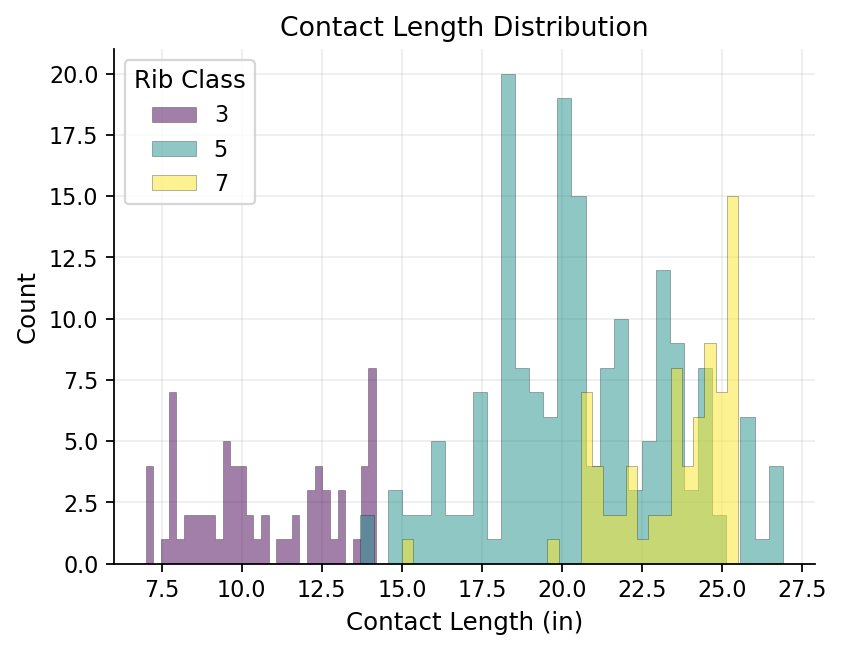

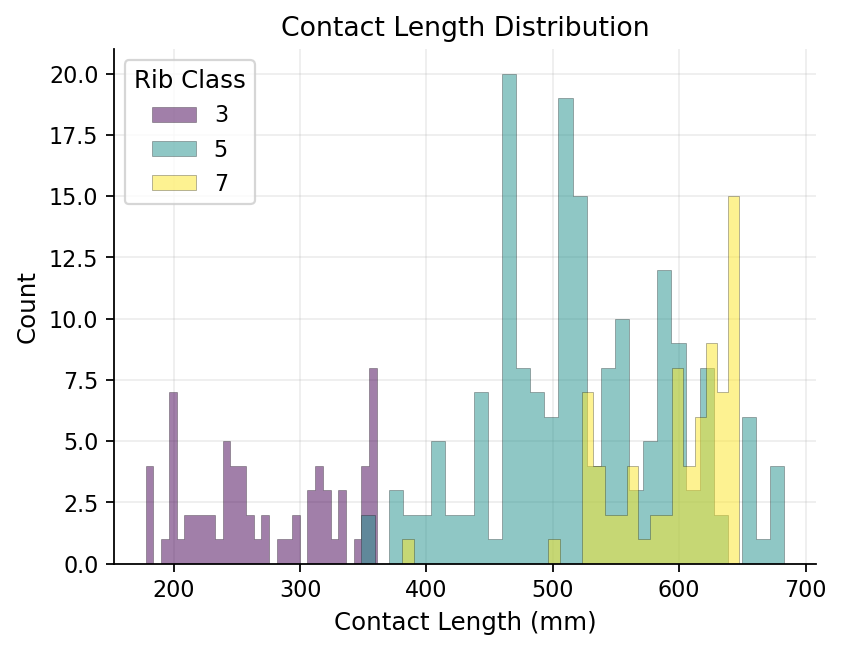

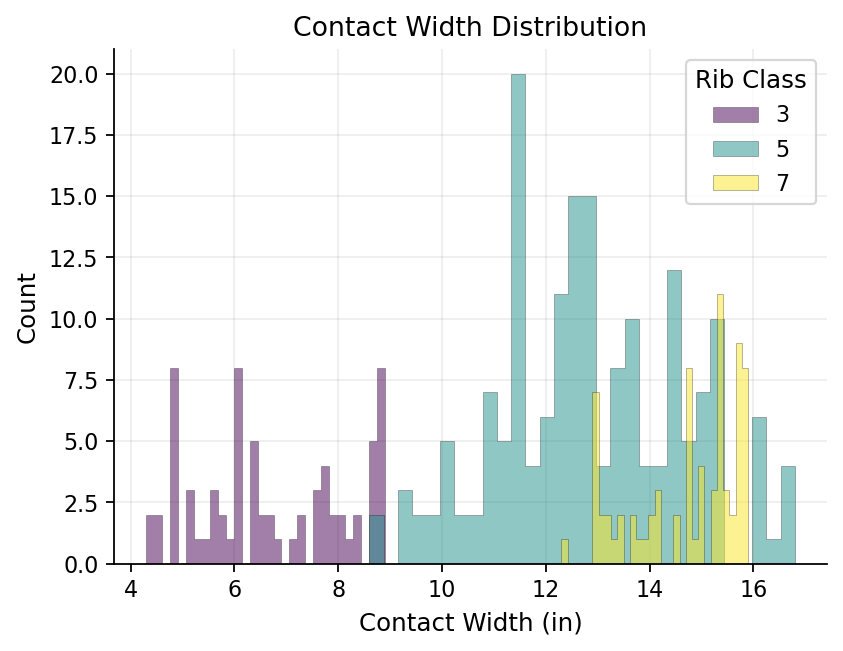

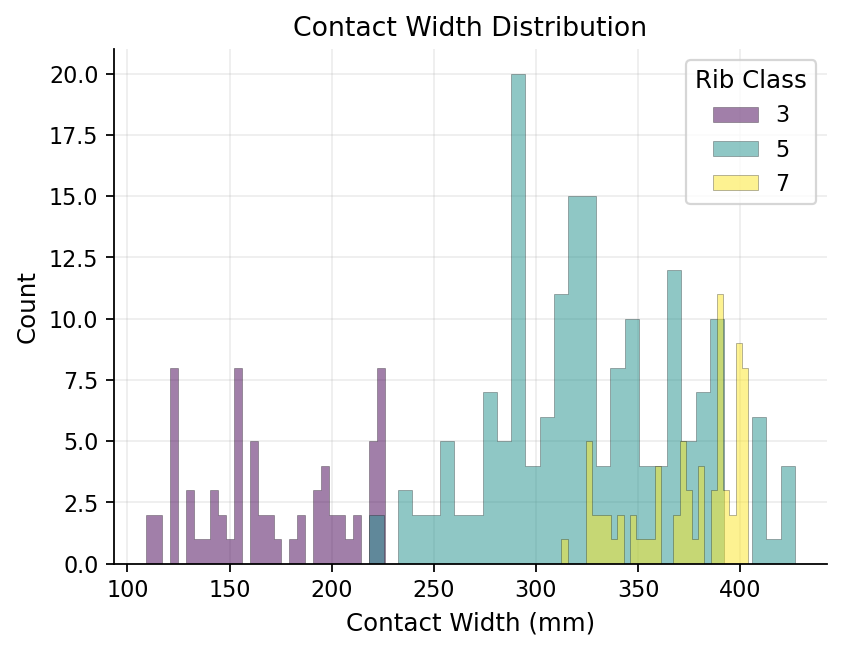

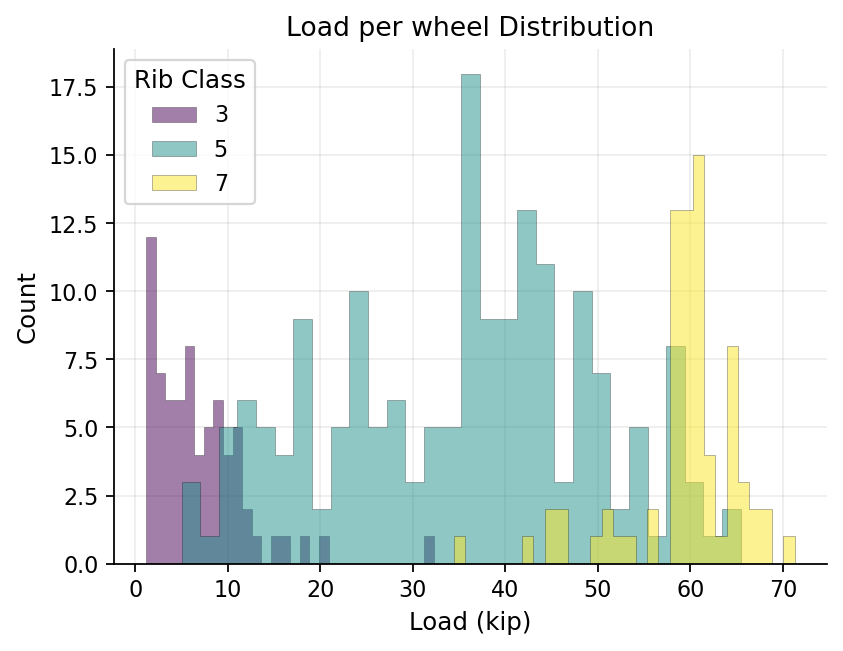

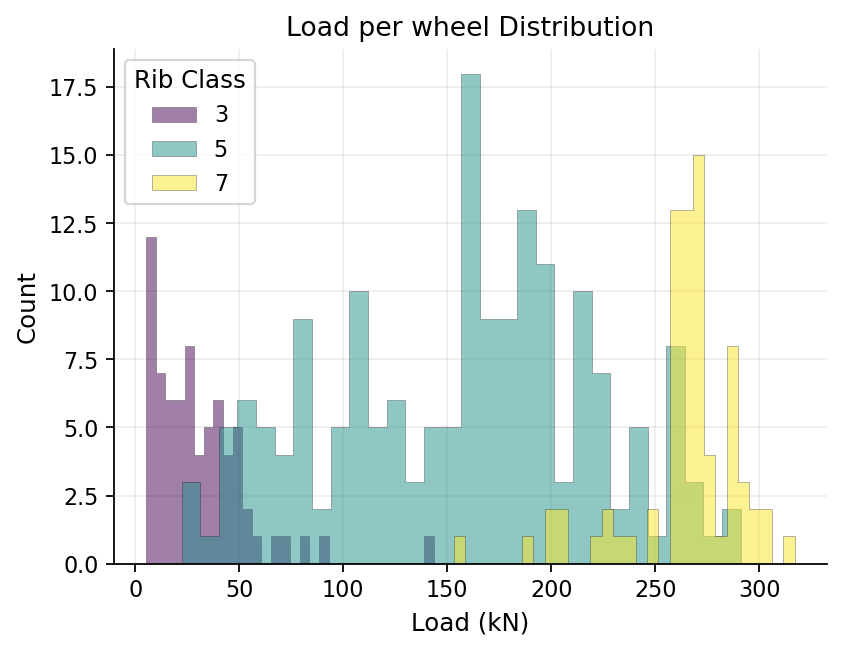

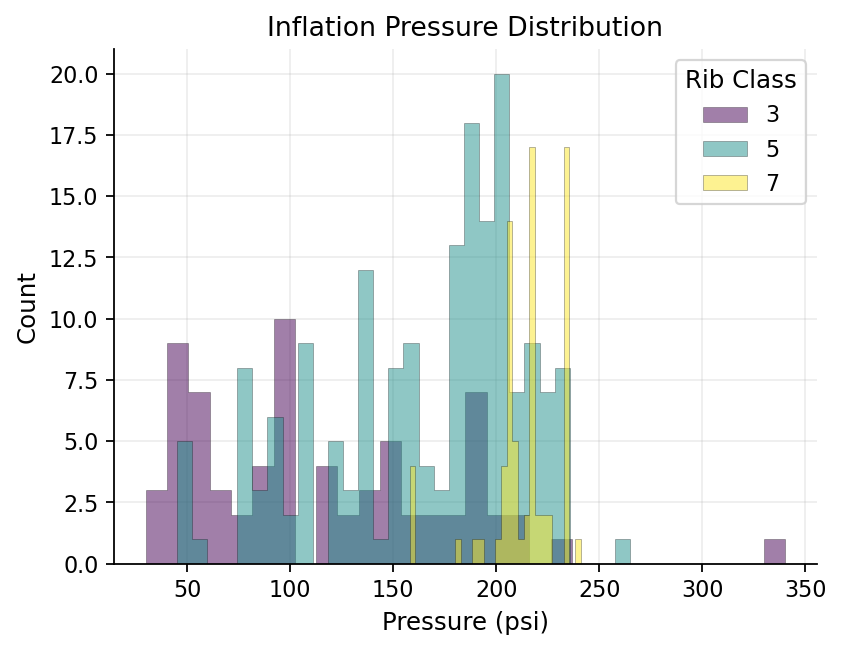

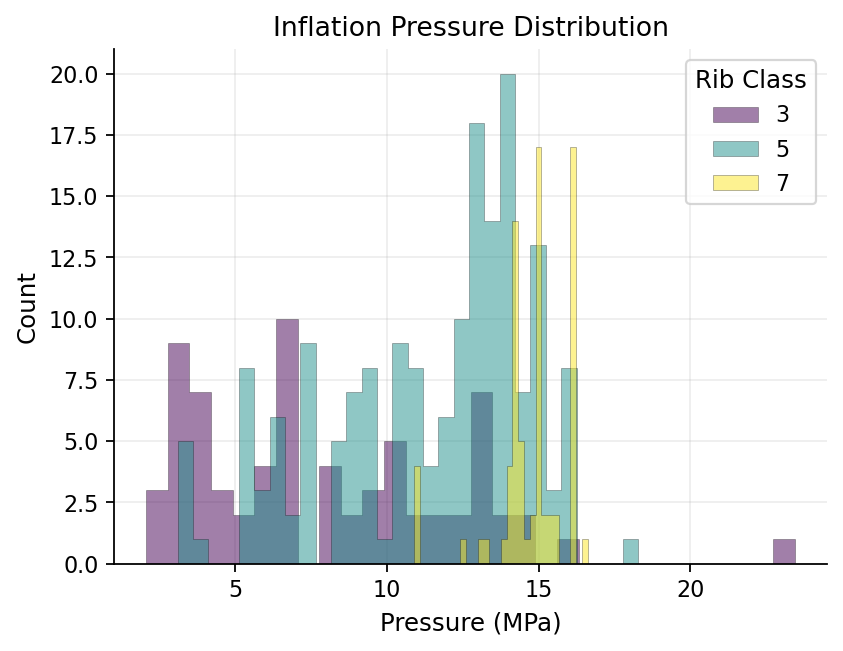

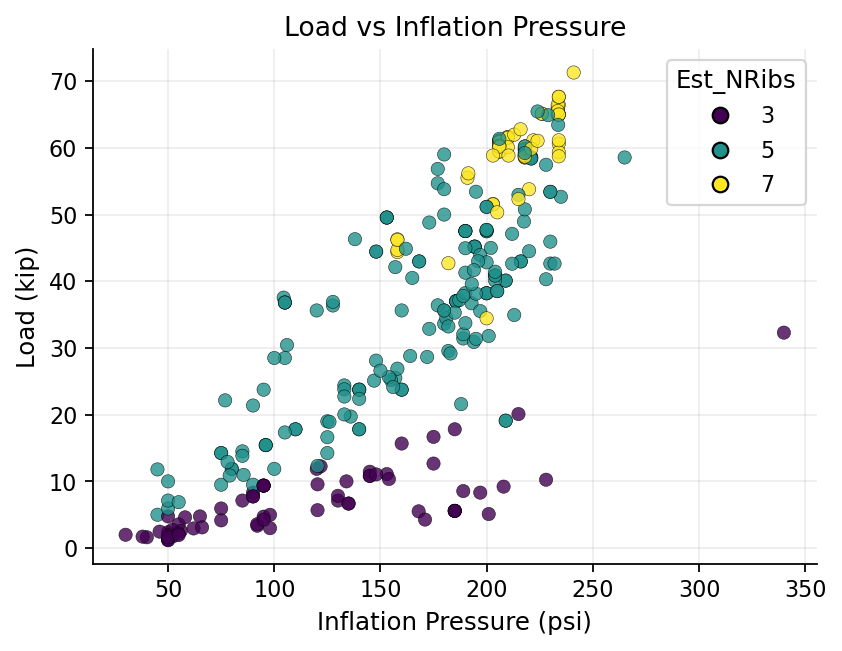

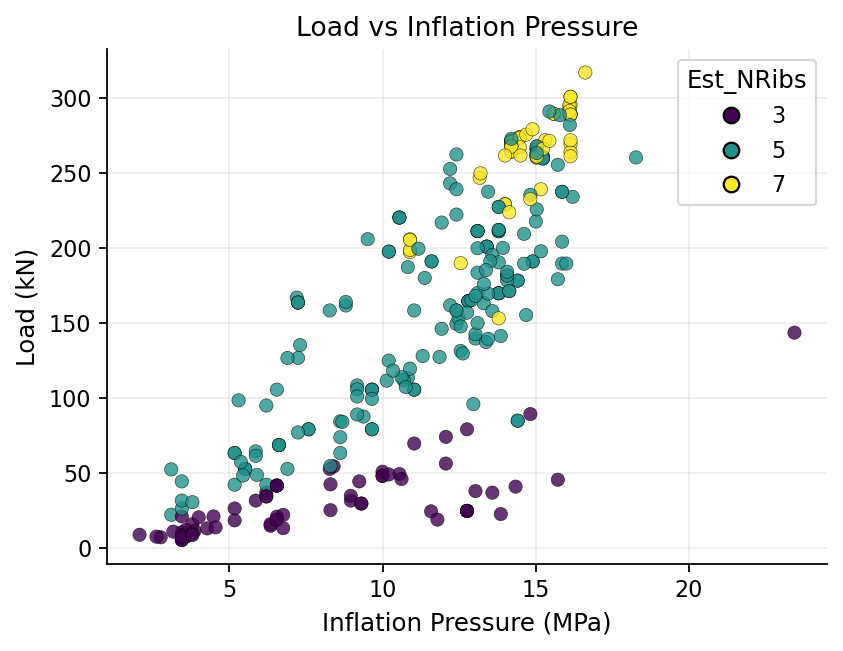

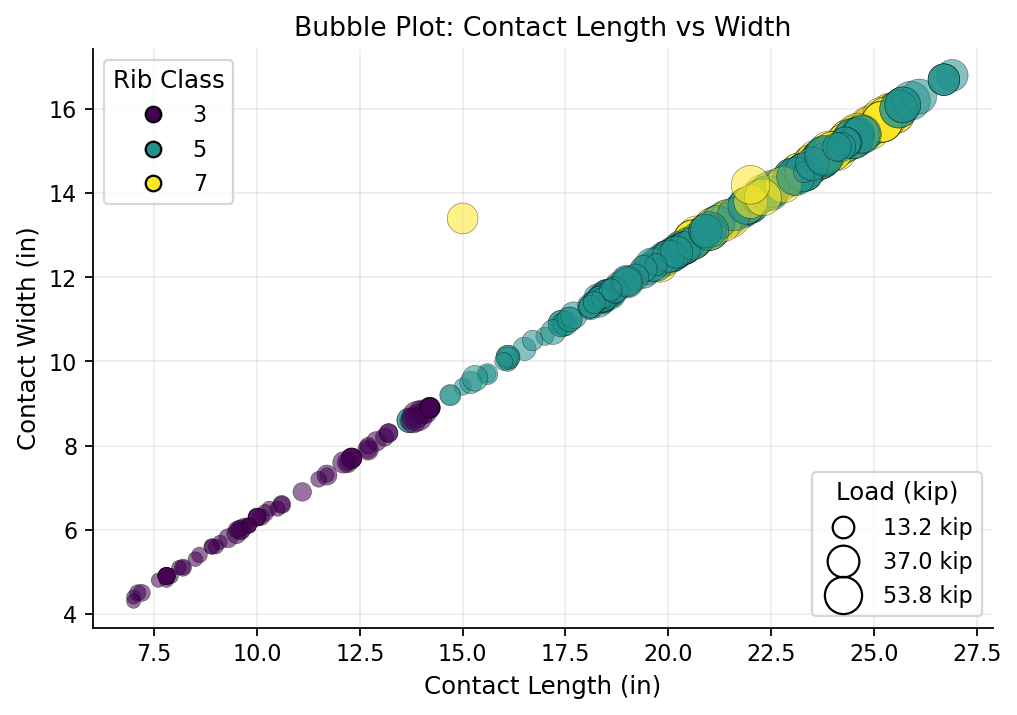

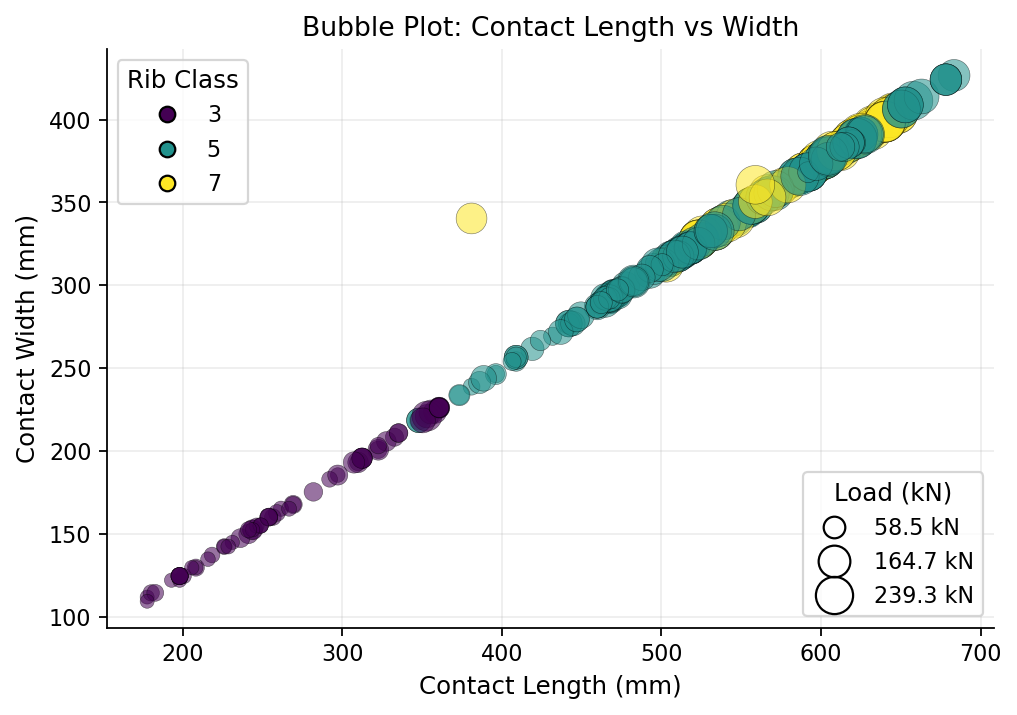

C:\Users\johannc2\AppData\Local\Temp\ipykernel_28460\1801857791.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True, widths=0.58, medianprops=dict(linewidth=1.6), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))


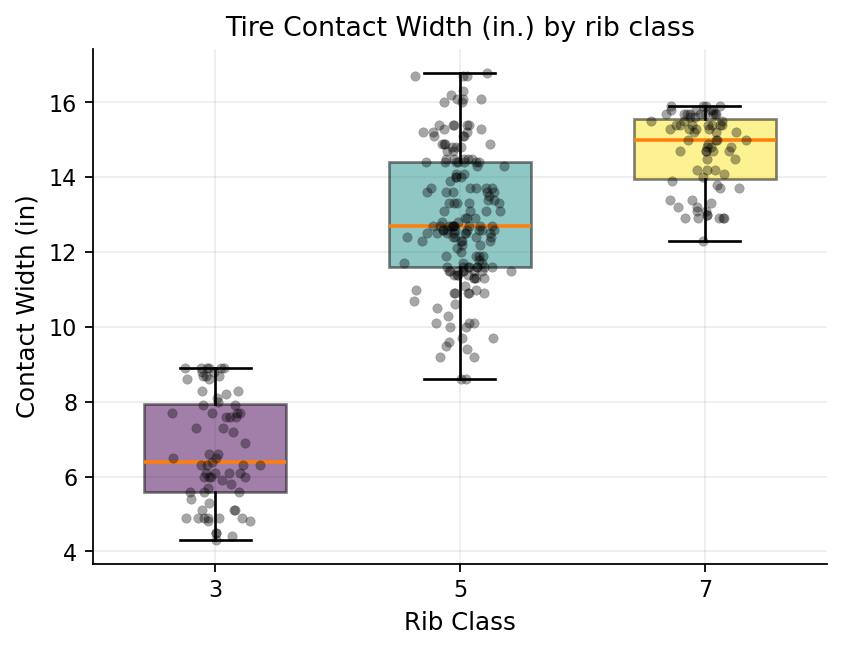

C:\Users\johannc2\AppData\Local\Temp\ipykernel_28460\1801857791.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True, widths=0.58, medianprops=dict(linewidth=1.6), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))


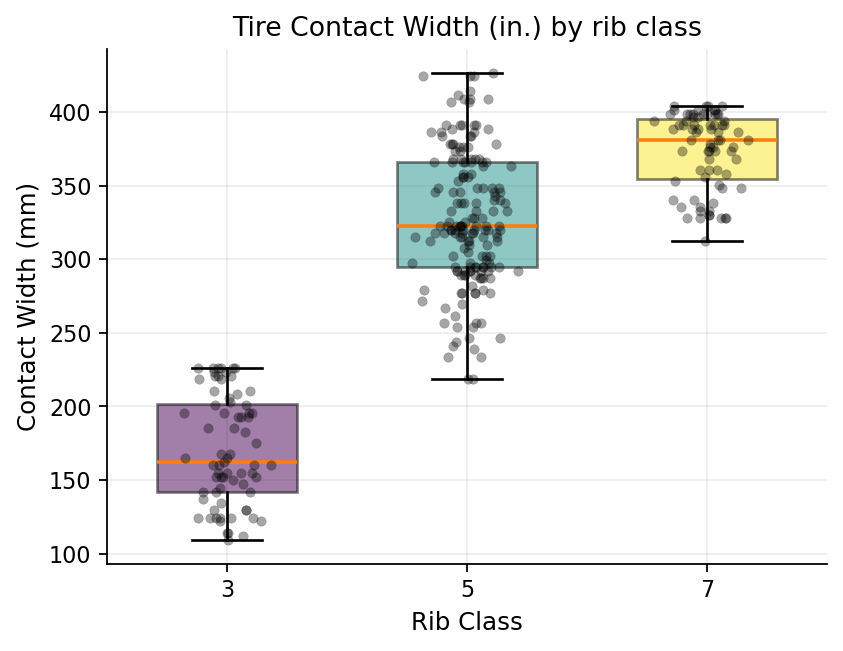

C:\Users\johannc2\AppData\Local\Temp\ipykernel_28460\1801857791.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True, widths=0.58, medianprops=dict(linewidth=1.6), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))


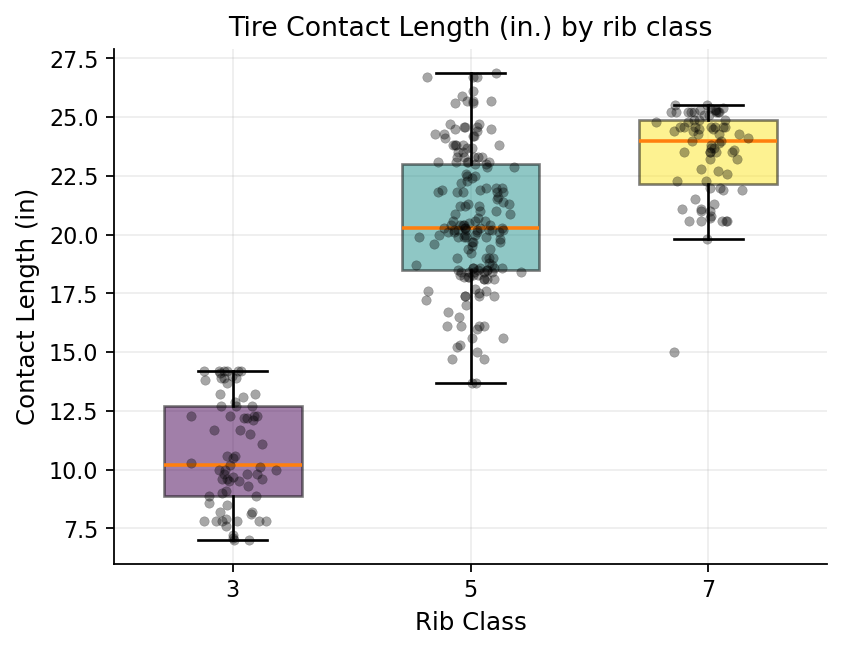

C:\Users\johannc2\AppData\Local\Temp\ipykernel_28460\1801857791.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True, widths=0.58, medianprops=dict(linewidth=1.6), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))


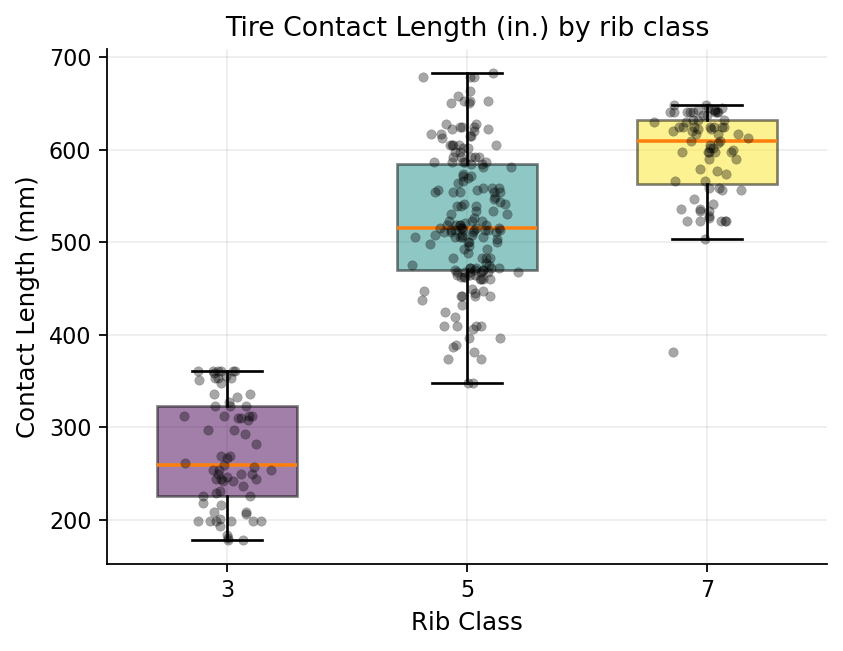

C:\Users\johannc2\AppData\Local\Temp\ipykernel_28460\1801857791.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True, widths=0.58, medianprops=dict(linewidth=1.6), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))


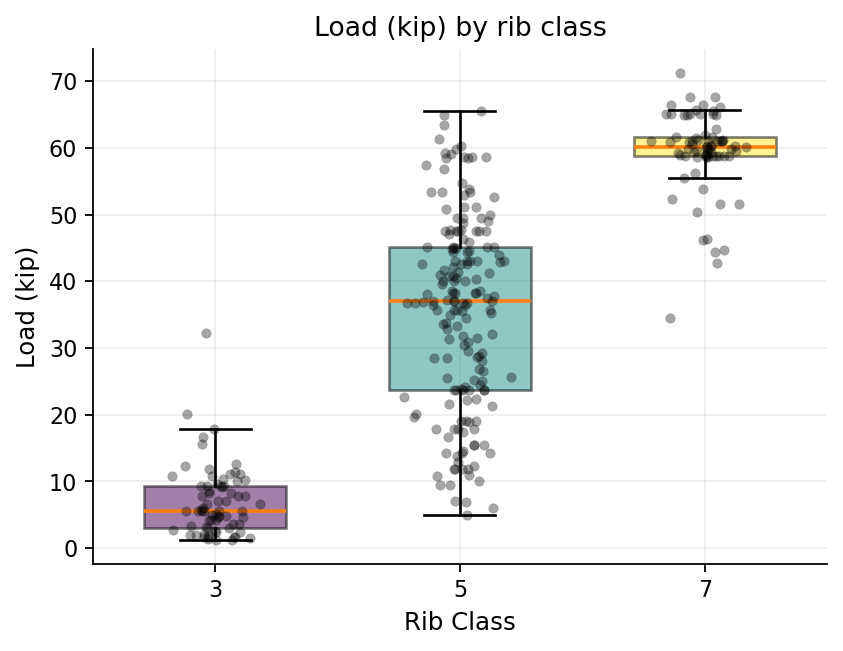

C:\Users\johannc2\AppData\Local\Temp\ipykernel_28460\1801857791.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True, widths=0.58, medianprops=dict(linewidth=1.6), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))


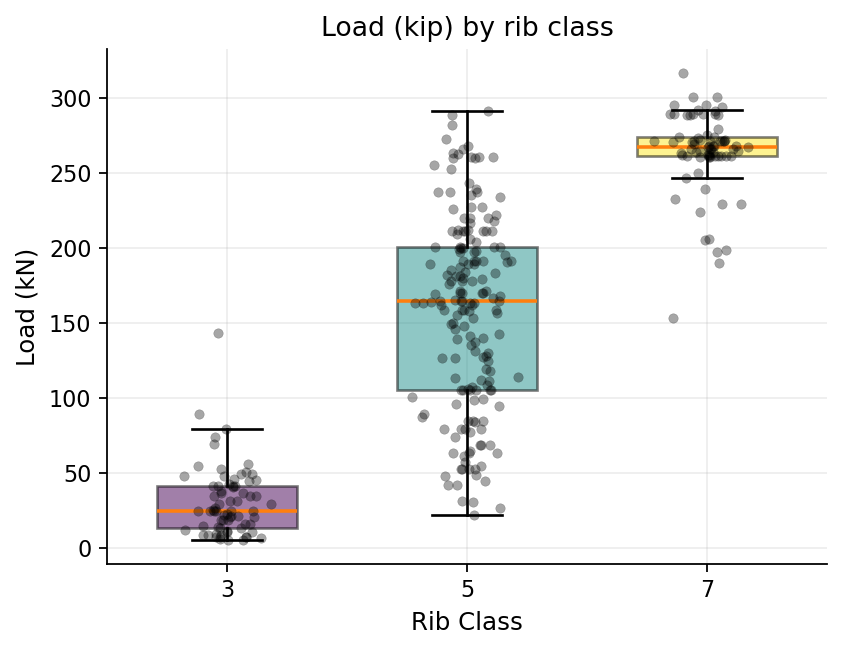

C:\Users\johannc2\AppData\Local\Temp\ipykernel_28460\1801857791.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True, widths=0.58, medianprops=dict(linewidth=1.6), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))


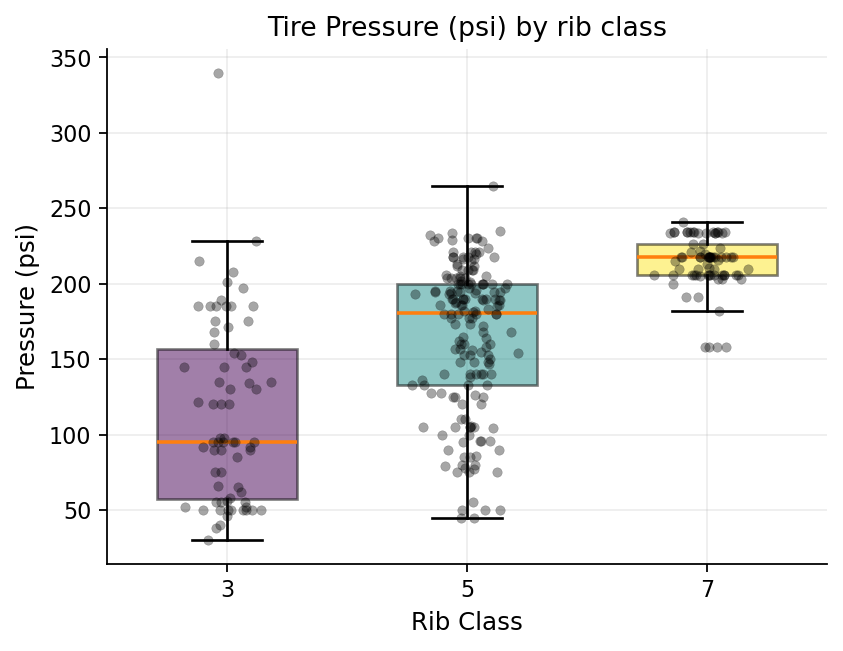

C:\Users\johannc2\AppData\Local\Temp\ipykernel_28460\1801857791.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True, widths=0.58, medianprops=dict(linewidth=1.6), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))


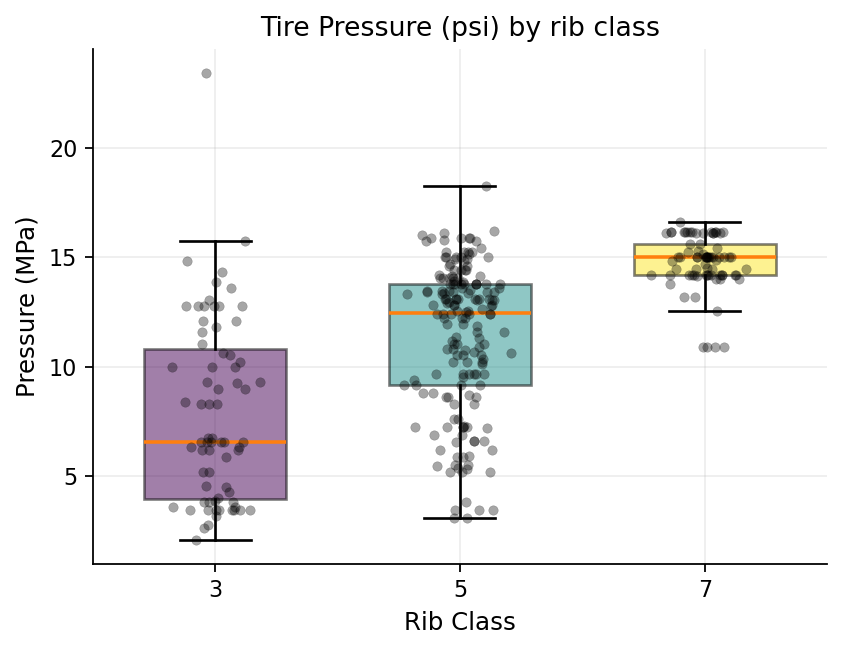

C:\Users\johannc2\AppData\Local\Temp\ipykernel_28460\1801857791.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True, widths=0.58, medianprops=dict(linewidth=1.6), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))


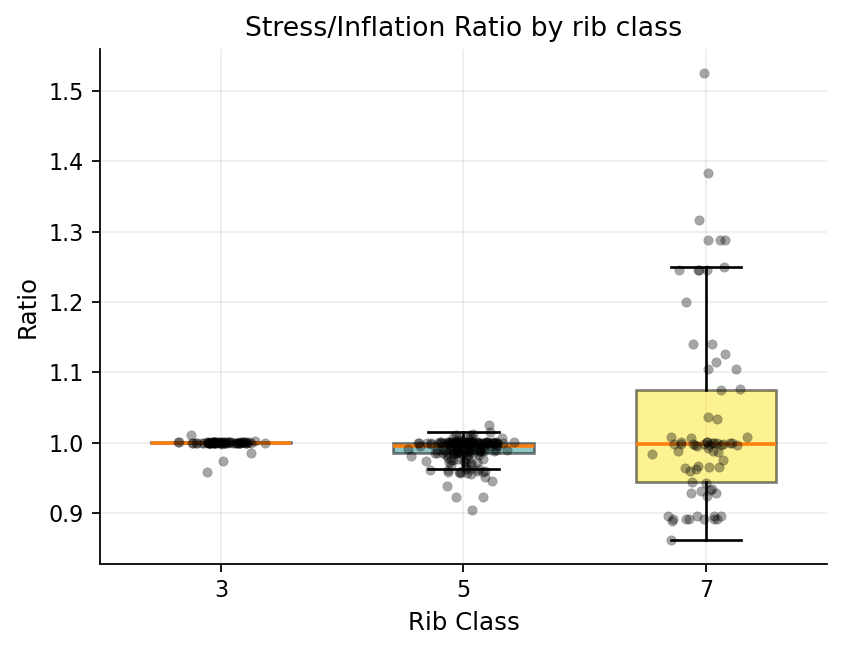

C:\Users\johannc2\AppData\Local\Temp\ipykernel_28460\1801857791.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True, widths=0.58, medianprops=dict(linewidth=1.6), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))


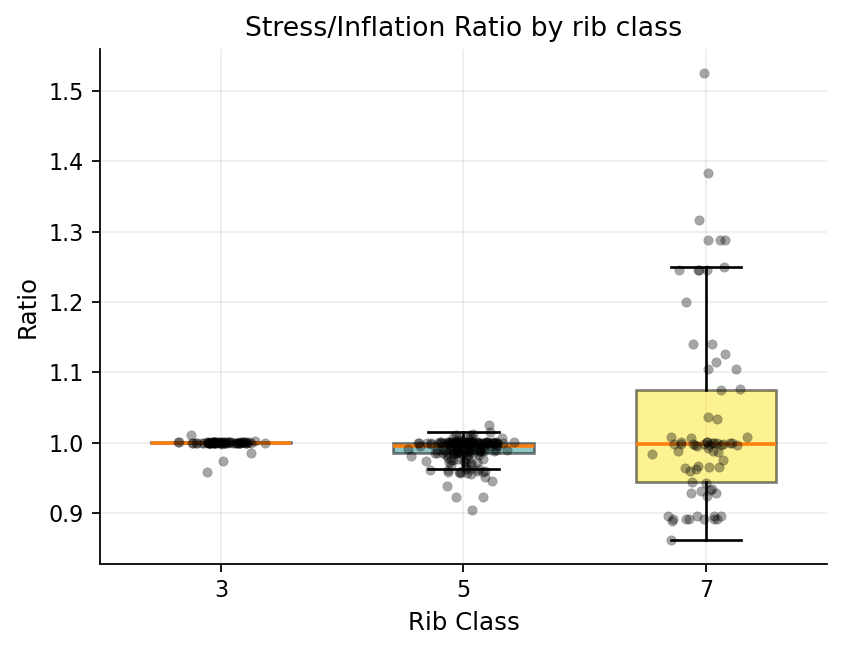

In [3]:
# Unit conversion helpers
def to_metric(df):
    d = df.copy()
    if col_len in d: d[col_len] = d[col_len] * 25.4
    if col_wid in d: d[col_wid] = d[col_wid] * 25.4
    if col_area in d: d[col_area] = d[col_area] * 645.16
    if col_load_lbs in d: d[col_load_lbs] = d[col_load_lbs] * 0.453592
    if 'Load (kip)' in d: d['Load (kip)'] = d['Load (kip)'] * 4.44822
    if col_press in d: d[col_press] = d[col_press] * 0.0689476
    if 'Mean Contact Stress (psi) = Load/Area' in d: d['Mean Contact Stress (psi) = Load/Area'] = d['Mean Contact Stress (psi) = Load/Area'] * 0.0689476
    if 'Load/Pressure (in^2)' in d: d['Load/Pressure (in^2)'] = d['Load/Pressure (in^2)'] * 6.4516
    return d

# 1) Histogram overlays
def plot_hist_by_class(col, units='imperial', bins=30, fname='hist'):
    if col is None or col not in df.columns: return
    d = df.copy() if units == 'imperial' else to_metric(df)
    fig, ax = plt.subplots(figsize=(5.4, 4.2))
    for cls in class_order:
        s = pd.to_numeric(d.loc[d[col_ribs] == cls, col], errors='coerce').dropna()
        if len(s) == 0: continue
        ax.hist(s, bins=bins, alpha=0.5, color=class_to_color[cls], edgecolor='k', linewidth=0.25, label=f'{cls}', histtype='stepfilled')
    title = {
        col_len: 'Contact Length Distribution',
        col_wid: 'Contact Width Distribution',
        'Load (kip)': 'Load per wheel Distribution',
        col_press: 'Inflation Pressure Distribution'
    }.get(col, col)
    xlabel = {
        col_len: 'Contact Length (in)' if units=='imperial' else 'Contact Length (mm)',
        col_wid: 'Contact Width (in)' if units=='imperial' else 'Contact Width (mm)',
        'Load (kip)': 'Load (kip)' if units=='imperial' else 'Load (kN)',
        col_press: 'Pressure (psi)' if units=='imperial' else 'Pressure (MPa)'
    }.get(col, col)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(title='Rib Class', frameon=True, fancybox=True)
    _beautify_ax(ax)
    fig.tight_layout()
    _save_show(fig, f'{fname}_{units}')

# 2) Scatter: Load vs Pressure
def plot_scatter_load_vs_pressure(units='imperial', fname='scatter_load_vs_pressure'):
    if col_press is None or 'Load (kip)' not in df.columns: return
    d = df.copy() if units == 'imperial' else to_metric(df)
    d, _ = clean_for_plot(d, [col_press, 'Load (kip)'], col_ribs)
    fig, ax = plt.subplots(figsize=(5.4, 4.2))
    sc = ax.scatter(
        d[col_press], d['Load (kip)'],
        c=d[col_ribs].map(class_to_code), s=36, alpha=0.80,
        cmap=cmap_cls, norm=norm_cls, edgecolors='k', linewidths=0.25
    )
    ax.set_title('Load vs Inflation Pressure')
    ax.set_xlabel('Inflation Pressure (psi)' if units=='imperial' else 'Inflation Pressure (MPa)')
    ax.set_ylabel('Load (kip)' if units=='imperial' else 'Load (kN)')
    _beautify_ax(ax)
    legend_from_scatter(ax, sc, class_order, class_to_code, loc='best', frameon=True, fancybox=True)
    fig.tight_layout()
    _save_show(fig, f'{fname}_{units}')

# 3) Bubble: Length vs Width, size=Load
def plot_bubble_length_width_load(units='imperial', fname='bubble_length_width_load'):
    if col_len is None or col_wid is None or 'Load (kip)' not in df.columns: return
    d = df.copy() if units == 'imperial' else to_metric(df)
    d, _ = clean_for_plot(d, [col_len, col_wid, 'Load (kip)'], col_ribs)
    s = d['Load (kip)'].to_numpy(float)
    s_scaled = 40 + 320 * (s - np.nanmin(s)) / (np.nanmax(s) - np.nanmin(s) + 1e-12)
    fig, ax = plt.subplots(figsize=(6.5, 4.6))
    sc = ax.scatter(
        d[col_len], d[col_wid], s=s_scaled,
        c=d[col_ribs].map(class_to_code), alpha=0.55,
        cmap=cmap_cls, norm=norm_cls, edgecolors='k', linewidths=0.25
    )
    ax.set_title('Bubble Plot: Contact Length vs Width')
    ax.set_xlabel('Contact Length (in)' if units=='imperial' else 'Contact Length (mm)')
    ax.set_ylabel('Contact Width (in)' if units=='imperial' else 'Contact Width (mm)')
    _beautify_ax(ax)
    leg1 = legend_from_scatter(ax, sc, class_order, class_to_code, title='Rib Class', loc='upper left', frameon=True, fancybox=True)
    ax.add_artist(leg1)
    refs = np.unique(np.round(np.quantile(d['Load (kip)'], [0.25, 0.5, 0.75]), 2))
    size_handles = []
    label_unit = 'kip' if units == 'imperial' else 'kN'
    for ref in refs:
        ref_s = 40 + 320 * (ref - np.nanmin(s)) / (np.nanmax(s) - np.nanmin(s) + 1e-12)
        size_handles.append(Line2D([0], [0], marker='o', linestyle='', markerfacecolor='none', markeredgecolor='k', markersize=np.sqrt(ref_s), label=f'{ref:.1f} {label_unit}'))
    ax.legend(handles=size_handles, title='Load (kip)' if units=='imperial' else 'Load (kN)', loc='lower right', frameon=True, fancybox=True)
    fig.tight_layout()
    _save_show(fig, f'{fname}_{units}')

# 4) Boxplots by rib class
def plot_box_by_ribs(col, units='imperial', fname='box'):
    if col is None or col not in df.columns: return
    d = df.copy() if units == 'imperial' else to_metric(df)
    d = d[[col_ribs, col]].dropna()
    if len(d) == 0: return
    d[col_ribs] = pd.to_numeric(d[col_ribs], errors='coerce')
    d = d.dropna(subset=[col_ribs])
    d[col_ribs] = d[col_ribs].astype(int)
    classes = sorted(d[col_ribs].unique())
    groups = [d.loc[d[col_ribs] == k, col].to_numpy(dtype=float) for k in classes]
    labels = [str(k) for k in classes]
    fig, ax = plt.subplots(figsize=(5.4, 4.2))
    bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True, widths=0.58, medianprops=dict(linewidth=1.6), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), boxprops=dict(linewidth=1.2))
    for i, k in enumerate(classes):
        c = class_to_color.get(k, (0.5, 0.5, 0.5, 1.0))
        bp['boxes'][i].set_facecolor(c)
        bp['boxes'][i].set_alpha(0.5)
        bp['boxes'][i].set_edgecolor('k')
    rng = np.random.default_rng(123)
    for i, y in enumerate(groups, start=1):
        if len(y) == 0: continue
        x = i + rng.normal(0.0, 0.08, size=len(y))
        ax.scatter(x, y, s=18, alpha=0.35, color='black', linewidths=0.2, edgecolors='k', zorder=3)
    ax.set_title(f'{col} by rib class')
    ax.set_xlabel('Rib Class')
    ylabel = {
        col_len: 'Contact Length (in)' if units=='imperial' else 'Contact Length (mm)',
        col_wid: 'Contact Width (in)' if units=='imperial' else 'Contact Width (mm)',
        'Load (kip)': 'Load (kip)' if units=='imperial' else 'Load (kN)',
        col_press: 'Pressure (psi)' if units=='imperial' else 'Pressure (MPa)',
        'Stress/Inflation Ratio': 'Ratio'
    }.get(col, col)
    ax.set_ylabel(ylabel)
    _beautify_ax(ax)
    fig.tight_layout()
    _save_show(fig, f'{fname}_{units}')
    
    
# --- Call all plots in both units ---
plot_hist_by_class(col_len, units='imperial', fname='hist_contact_length_by_ribs')
plot_hist_by_class(col_len, units='metric', fname='hist_contact_length_by_ribs')
plot_hist_by_class(col_wid, units='imperial', fname='hist_contact_width_by_ribs')
plot_hist_by_class(col_wid, units='metric', fname='hist_contact_width_by_ribs')
plot_hist_by_class('Load (kip)', units='imperial', fname='hist_load_by_ribs')
plot_hist_by_class('Load (kip)', units='metric', fname='hist_load_by_ribs')
plot_hist_by_class(col_press, units='imperial', fname='hist_pressure_by_ribs')
plot_hist_by_class(col_press, units='metric', fname='hist_pressure_by_ribs')

plot_scatter_load_vs_pressure(units='imperial')
plot_scatter_load_vs_pressure(units='metric')

plot_bubble_length_width_load(units='imperial')
plot_bubble_length_width_load(units='metric')

plot_box_by_ribs(col_wid, units='imperial', fname='box_width_by_ribs')
plot_box_by_ribs(col_wid, units='metric', fname='box_width_by_ribs')
plot_box_by_ribs(col_len, units='imperial', fname='box_length_by_ribs')
plot_box_by_ribs(col_len, units='metric', fname='box_length_by_ribs')
plot_box_by_ribs('Load (kip)', units='imperial', fname='box_load_by_ribs')
plot_box_by_ribs('Load (kip)', units='metric', fname='box_load_by_ribs')
plot_box_by_ribs(col_press, units='imperial', fname='box_pressure_by_ribs')
plot_box_by_ribs(col_press, units='metric', fname='box_pressure_by_ribs')
plot_box_by_ribs('Stress/Inflation Ratio', units='imperial', fname='box_stress_infl_ratio_by_ribs')
plot_box_by_ribs('Stress/Inflation Ratio', units='metric', fname='box_stress_infl_ratio_by_ribs')


In [20]:
def plot_joint_bubble_length_width_with_marginals(units="imperial",
                                                  bins=28,
                                                  fname_base="joint_bubble_length_width"):
    # ---- guardrails (no silent fails) ----
    if col_len is None or col_wid is None:
        print("[jointplot] Missing length/width columns:", col_len, col_wid)
        return
    if "Load (kip)" not in df.columns:
        print("[jointplot] Missing 'Load (kip)' column in df.columns")
        return
    if col_ribs is None:
        print("[jointplot] Missing rib class column (col_ribs is None)")
        return

    # pick units
    d0 = df.copy() if units == "imperial" else to_metric(df)

    # clean
    d, _ = clean_for_plot(d0, [col_len, col_wid, "Load (kip)"], col_ribs)
    if len(d) == 0:
        print(f"[jointplot] No rows after cleaning for units={units}.")
        return

    # ---- load handling inside the function ----
    load_vals = d["Load (kip)"].to_numpy(float)
    load_unit  = "kip" if units == "imperial" else "kN"
    load_title = "Load (kip)" if units == "imperial" else "Load (kN)"

    # bubble size scaling
    s_scaled = 40 + 320 * (load_vals - np.nanmin(load_vals)) / (
        np.nanmax(load_vals) - np.nanmin(load_vals) + 1e-12
    )

    # labels
    xlab = "Contact Length (in)" if units == "imperial" else "Contact Length (mm)"
    ylab = "Contact Width (in)"  if units == "imperial" else "Contact Width (mm)"

    # ---- layout ----
    fig = plt.figure(figsize=(7.0, 4.7), dpi=200, constrained_layout=True)

    gs = GridSpec(
        2, 2, figure=fig,
        width_ratios=[6.6, 1.0],   # main wider, right thinner
        height_ratios=[1.0, 3.6]   # top shorter, main shorter (but still dominant)
    )

    ax_top   = fig.add_subplot(gs[0, 0])                 # TOP: Length hist
    ax_main  = fig.add_subplot(gs[1, 0])                 # MAIN: Scatter
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main) # RIGHT: Width hist (horizontal)
    ax_empty = fig.add_subplot(gs[0, 1])                 # Legends
    ax_empty.axis("off")

    # ---- main scatter ----
    sc = ax_main.scatter(
        d[col_len], d[col_wid],
        s=s_scaled,
        c=d[col_ribs].map(class_to_code),
        alpha=0.55,
        cmap=cmap_cls, norm=norm_cls,
        edgecolors="k", linewidths=0.25
    )
    # REMOVE TITLES
    # ax_main.set_title(...)
    ax_main.set_xlabel(xlab)
    ax_main.set_ylabel(ylab)
    ax_main.minorticks_on()
    ax_main.grid(which="minor", linestyle="--", linewidth=0.6, alpha=0.35, color="lightgrey")
    _beautify_ax(ax_main)

    # ---- top: CONTACT LENGTH distribution ----
    len_all = d[col_len].to_numpy(float)
    l_bins = np.histogram_bin_edges(len_all, bins=bins)

    for cls in class_order:
        s_l = pd.to_numeric(d.loc[d[col_ribs] == cls, col_len], errors="coerce").dropna()
        if len(s_l) == 0:
            continue
        ax_top.hist(
            s_l, bins=l_bins,
            alpha=0.50,
            color=class_to_color[cls],
            edgecolor="k", linewidth=0.25,
            histtype="stepfilled"
        )

    # REMOVE TITLE
    # ax_top.set_title("Contact Length Distribution")
    ax_top.set_ylabel("Count")
    _beautify_ax(ax_top)
    ax_top.tick_params(axis="x", labelbottom=False)

    # ---- right: CONTACT WIDTH distribution (horizontal) ----
    width_all = d[col_wid].to_numpy(float)
    w_bins = np.histogram_bin_edges(width_all, bins=bins)

    for cls in class_order:
        s_w = pd.to_numeric(d.loc[d[col_ribs] == cls, col_wid], errors="coerce").dropna()
        if len(s_w) == 0:
            continue
        ax_right.hist(
            s_w, bins=w_bins,
            orientation="horizontal",
            alpha=0.50,
            color=class_to_color[cls],
            edgecolor="k", linewidth=0.25,
            histtype="stepfilled"
        )

    # REMOVE TITLE
    # ax_right.set_title("Contact Width Distribution")
    ax_right.set_xlabel("Count")
    _beautify_ax(ax_right)
    ax_right.tick_params(axis="y", labelleft=False)

    # ---- legends ----
    leg1 = legend_from_scatter(
        ax_empty, sc,
        class_order, class_to_code,
        title="Rib Class",
        loc="upper left",
        frameon=True, fancybox=True
    )
    ax_empty.add_artist(leg1)

    refs = np.unique(np.round(np.quantile(load_vals, [0.25, 0.5, 0.75]), 2))
    size_handles = []
    
    for ref in refs:
        ref_s = 40 + 320 * (ref - np.nanmin(load_vals)) / (
            np.nanmax(load_vals) - np.nanmin(load_vals) + 1e-12
        )
        size_handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="",
                markerfacecolor="none",
                markeredgecolor="k",
                markersize=np.sqrt(ref_s),
                label=f"{ref:.1f} {load_unit}"
            )
        )
    ax_main.legend(
        handles=size_handles,
        title=load_title,
        loc="lower right",
        frameon=True, 
        fancybox=True
    )

    print(f"[jointplot] Rendering units={units} with n={len(d)} points.")
    plt.show()


[jointplot] Rendering units=metric with n=322 points.


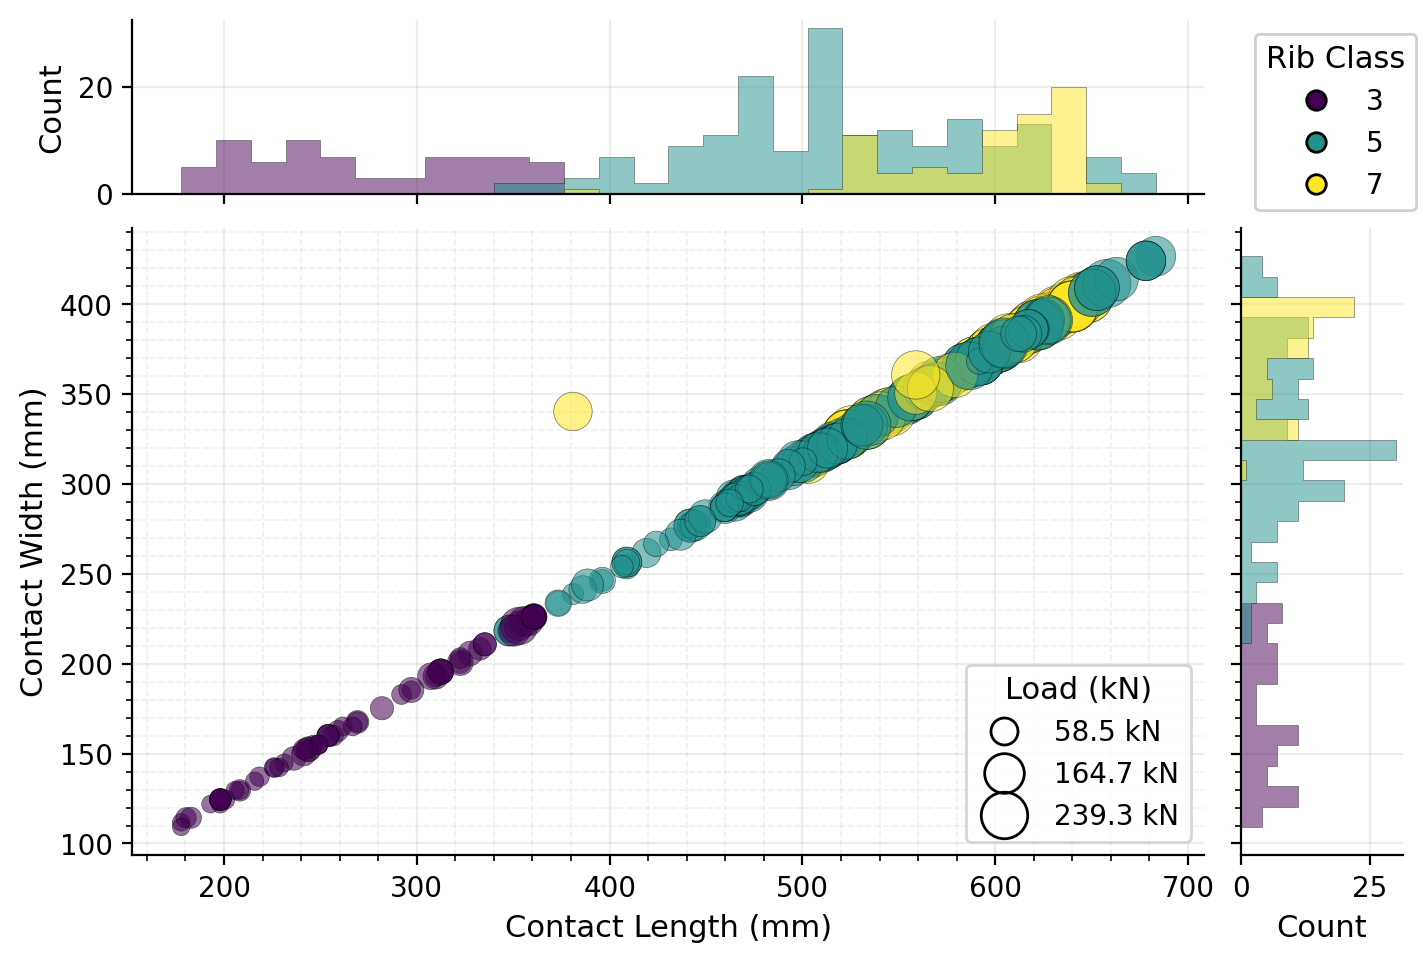

In [21]:
plot_joint_bubble_length_width_with_marginals(units="metric")

In [ ]:
# ============================================================================
# GEAR CONFIGURATION LAYOUT — Top-down view of wheel contact patches
# ============================================================================

def parse_semicolon(cell):
    """Convert semicolon-separated string to list of floats."""
    if pd.isna(cell) or str(cell).strip() == "":
        return []
    try:
        return [float(x) for x in str(cell).split(";") if x.strip()]
    except ValueError:
        return []


def plot_gear_layouts(units="imperial", fname_base="gear_layout"):
    """
    Top-down view of main-gear wheel contact patches for representative aircraft.
    Each subplot shows one aircraft; tire patches drawn as rectangles at wheel
    coordinates, colored by rib class.
    """
    # --- Column references ---
    c_name  = "Airplane Name"
    c_wx    = "WheelCoord_X (in.)"
    c_wy    = "WheelCoord_Y (in.)"
    c_tw    = "Tire Contact Width (in.)"
    c_tl    = "Tire Contact Length (in.)"
    c_nw    = "Number Wheels"
    c_ribs  = col_ribs

    needed = [c_name, c_wx, c_wy, c_tw, c_tl, c_ribs]
    for c in needed:
        if c not in df.columns:
            print(f"[gear_layout] Missing column: {c}")
            return

    # --- Select representative aircraft across size classes ---
    # Order: small → large; pick the first match found in the data
    candidates = [
        ("GA / Light",        ["Cessna 172 Skyhawk", "Cessna 182 Skylane", "Piper Cherokee"]),
        ("Business Jet",      ["Learjet 35", "Learjet 60", "Citation III", "Challenger CL-604"]),
        ("Regional Turbo.",   ["DHC-8-300, Srs 300", "DHC-8-400", "ATR 72-500", "Saab 340"]),
        ("Regional Jet",      ["CRJ200LR", "CRJ200", "CRJ100LR", "CRJ700", "ERJ 145"]),
        ("Narrow-Body",       ["B737-800", "B737-300", "A320-200", "A321-200", "B757-200"]),
        ("Wide-Body Twin",    ["ICT-B777-300ER", "B777-300ER", "B777-200", "B787-8", "A330-300"]),
        ("Wide-Body Quad",    ["ICT-A380-800", "A380-800", "B747-400", "B747-8"]),
        ("Military Transport",["C-17A Globemaster III", "C-130H Hercules", "C-5A Galaxy"]),
    ]

    selected = []
    for label, names in candidates:
        for n in names:
            row = df[df[c_name] == n]
            if len(row) == 0:
                continue
            r = row.iloc[0]
            xs = parse_semicolon(r[c_wx])
            ys = parse_semicolon(r[c_wy])
            tw = r[c_tw]
            tl = r[c_tl]
            if len(xs) < 2 or len(ys) < 2 or pd.isna(tw) or pd.isna(tl) or tw <= 0 or tl <= 0:
                continue
            selected.append((label, n, xs, ys, float(tw), float(tl), int(r[c_ribs])))
            break

    if len(selected) == 0:
        print("[gear_layout] No aircraft with valid wheel coordinates found.")
        return

    # --- Unit conversion ---
    scale = 1.0
    patch_unit = "in"
    if units == "metric":
        scale = 25.4
        patch_unit = "mm"

    # --- Layout: one subplot per aircraft ---
    n = len(selected)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 4.2 * nrows))
    if n == 1:
        axes = np.array([axes])
    axes = np.atleast_2d(axes)

    for idx, (label, name, xs, ys, tw, tl, ribs) in enumerate(selected):
        r_idx, c_idx = divmod(idx, ncols)
        ax = axes[r_idx, c_idx]

        xs_s = np.array(xs) * scale
        ys_s = np.array(ys) * scale
        hw = tw * scale / 2.0   # half-width  (transverse)
        hl = tl * scale / 2.0   # half-length (longitudinal)

        color = class_to_color.get(ribs, "steelblue")

        # Draw each tire contact patch as a rectangle
        from matplotlib.patches import Rectangle, FancyBboxPatch
        for xi, yi in zip(xs_s, ys_s):
            rect = FancyBboxPatch(
                (xi - hw, yi - hl), tw * scale, tl * scale,
                boxstyle="round,pad=0",
                linewidth=0.6, edgecolor="k",
                facecolor=color, alpha=0.65
            )
            ax.add_patch(rect)
            # Wheel center marker
            ax.plot(xi, yi, "k+", markersize=4, markeredgewidth=0.5)

        # Axis styling
        pad_x = max(hw * 3, 30 * scale)
        pad_y = max(hl * 3, 30 * scale)
        all_x = xs_s
        all_y = ys_s
        x_mid = (all_x.min() + all_x.max()) / 2
        y_mid = (all_y.min() + all_y.max()) / 2
        x_range = max(all_x.max() - all_x.min() + 2 * pad_x, 2 * pad_x)
        y_range = max(all_y.max() - all_y.min() + 2 * pad_y, 2 * pad_y)
        half_span = max(x_range, y_range) / 2  # keep square aspect
        ax.set_xlim(x_mid - half_span, x_mid + half_span)
        ax.set_ylim(y_mid - half_span, y_mid + half_span)
        ax.set_aspect("equal")
        ax.axhline(0, color="grey", linewidth=0.4, linestyle="--", alpha=0.5)
        ax.axvline(0, color="grey", linewidth=0.4, linestyle="--", alpha=0.5)

        short_name = name.replace("ICT-", "")
        ax.set_title(f"{short_name}\n({label}, {ribs}-rib)", fontsize=9, fontweight="bold")
        ax.set_xlabel(f"Transverse ({patch_unit})", fontsize=8)
        ax.set_ylabel(f"Longitudinal ({patch_unit})", fontsize=8)
        ax.tick_params(labelsize=7)
        _beautify_ax(ax)

    # Turn off unused axes
    for idx in range(n, nrows * ncols):
        r_idx, c_idx = divmod(idx, ncols)
        axes[r_idx, c_idx].axis("off")

    fig.suptitle(
        "Main Gear Wheel Contact Patch Layouts",
        fontsize=13, fontweight="bold", y=1.02
    )
    fig.tight_layout()
    _save_show(fig, f"{fname_base}_{units}")


plot_gear_layouts(units="imperial")
plot_gear_layouts(units="metric")